In [156]:
text = """ Deep learning is a subset of machine learning that uses neural networks with multiple hidden layers to learn complex patterns from data. A common interview question is what distinguishes deep learning from traditional machine learning. Traditional machine learning relies heavily on manual feature engineering, while deep learning automatically learns hierarchical features from raw data. Another frequently asked question is what a neural network is. A neural network is inspired by the human brain and consists of layers of interconnected neurons, where each neuron performs a weighted sum followed by an activation function.
Interviewers often ask about the difference between artificial neural networks, convolutional neural networks, and recurrent neural networks. Artificial neural networks are basic feedforward networks, convolutional neural networks are designed for spatial data like images, and recurrent neural networks are designed for sequential data such as text and time series. A popular question is why convolutional neural networks are effective for image processing. CNNs use convolutional layers to detect local patterns like edges and textures and pooling layers to reduce spatial dimensions.
Another common question is what an activation function is and why it is needed. Activation functions introduce nonlinearity into the network, allowing it to learn complex relationships. Frequently mentioned activation functions include sigmoid, tanh, ReLU, Leaky ReLU, and softmax. ReLU is popular because it reduces the vanishing gradient problem and speeds up training. Softmax is commonly used in the output layer for multi-class classification problems.
Interviewers often ask about the vanishing and exploding gradient problems. The vanishing gradient problem occurs when gradients become very small during backpropagation, making it difficult for the network to learn. The exploding gradient problem occurs when gradients become too large, causing unstable training. Techniques such as proper weight initialization, batch normalization, gradient clipping, and using activation functions like ReLU help address these issues.
A very common interview topic is backpropagation. Backpropagation is an algorithm used to train neural networks by computing gradients of the loss function with respect to weights and updating them using gradient descent. Gradient descent itself is another frequently discussed concept. Variants such as batch gradient descent, stochastic gradient descent, and mini-batch gradient descent are often compared. Optimizers like Adam, RMSprop, and Adagrad are also popular interview topics.
Regularization techniques are often asked about to test understanding of overfitting. Overfitting occurs when a model performs well on training data but poorly on unseen data. Common regularization techniques include L1 regularization, L2 regularization, dropout, and early stopping. Dropout randomly disables neurons during training to prevent co-adaptation and improve generalization.
Loss functions are another important topic. Mean squared error is commonly used for regression problems, while cross-entropy loss is widely used for classification tasks. Binary cross-entropy is used for binary classification, and categorical cross-entropy is used for multi-class classification. Interviewers may ask why cross-entropy works well with softmax activation.
A frequently asked question is what batch normalization is and why it is useful. Batch normalization normalizes layer inputs during training, which helps stabilize and accelerate training. It also acts as a form of regularization. Closely related is the question of weight initialization. Techniques such as Xavier initialization and He initialization help maintain stable gradients across layers.
Recurrent neural networks are a major interview topic, especially for sequence modeling. A common question is why standard RNNs struggle with long-term dependencies. The answer involves vanishing gradients. This leads to questions about LSTM and GRU networks. LSTM networks use gates such as input, forget, and output gates to control information flow and retain long-term dependencies. GRUs are a simplified version of LSTMs with fewer gates.
Natural language processing questions are also common. Interviewers often ask how text data is represented numerically. Common techniques include one-hot encoding, word embeddings, Word2Vec, GloVe, and FastText. Word embeddings capture semantic relationships between words in a dense vector space. Another popular topic is sequence-to-sequence models used for machine translation and text generation.
Attention mechanisms and transformers are frequently discussed in modern deep learning interviews. Attention allows the model to focus on relevant parts of the input sequence. Transformers rely entirely on attention mechanisms and remove recurrence, enabling parallel computation. Self-attention and multi-head attention are key components of transformer models.
Another common interview question is what transfer learning is. Transfer learning involves using a pre-trained model and fine-tuning it on a new task. This is especially useful when labeled data is limited. Models like VGG, ResNet, BERT, and GPT are commonly mentioned examples. Interviewers may ask about fine-tuning versus feature extraction.
Evaluation metrics are also important. Accuracy, precision, recall, F1 score, ROC curve, and AUC are commonly discussed. For imbalanced datasets, accuracy alone is not sufficient, and precision-recall metrics are preferred. Confusion matrices are often used to analyze classification performance.
Finally, interviewers may ask about challenges in deep learning such as data requirements, computational cost, lack of interpretability, and ethical concerns. Explainability techniques like SHAP and LIME are sometimes mentioned. Questions about hardware accelerators such as GPUs and TPUs are also common, as deep learning training is computationally intensive.
"""

In [157]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

Tokenization

In [158]:
!pip install nltk

In [159]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [160]:
from nltk.tokenize import word_tokenize
tokens = word_tokenize(text.lower())
tokens[:4]

['deep', 'learning', 'is', 'a']

Building Vocabulary

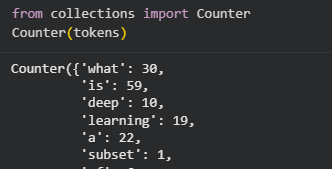

In [161]:
from collections import Counter
vocab = {'<unk>':0}

for token in Counter(tokens).keys():
  if token not in vocab:
    vocab[token] = len(vocab)

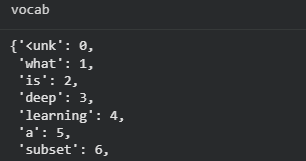

In [162]:
len(vocab)

356

Split corpus into sentences

In [163]:
input_sentences = text.split('\n')
input_sentences[:3]

[' Deep learning is a subset of machine learning that uses neural networks with multiple hidden layers to learn complex patterns from data. A common interview question is what distinguishes deep learning from traditional machine learning. Traditional machine learning relies heavily on manual feature engineering, while deep learning automatically learns hierarchical features from raw data. Another frequently asked question is what a neural network is. A neural network is inspired by the human brain and consists of layers of interconnected neurons, where each neuron performs a weighted sum followed by an activation function.',
 'Interviewers often ask about the difference between artificial neural networks, convolutional neural networks, and recurrent neural networks. Artificial neural networks are basic feedforward networks, convolutional neural networks are designed for spatial data like images, and recurrent neural networks are designed for sequential data such as text and time series

Convert text to indices

In [164]:
def text_to_indices(sentence, vocab):
  numerical_sentence = []
  for token in sentence:
    if token in vocab:
      numerical_sentence.append(vocab[token])
    else:
      numerical_sentence.append(vocab['<unk>'])
  return numerical_sentence

In [165]:
text_to_indices(word_tokenize(input_sentences[0].lower()), vocab)

[1,
 2,
 3,
 4,
 5,
 6,
 7,
 2,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 4,
 23,
 24,
 25,
 3,
 26,
 27,
 1,
 2,
 20,
 28,
 7,
 2,
 22,
 28,
 7,
 2,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 1,
 2,
 37,
 38,
 39,
 40,
 20,
 41,
 21,
 22,
 42,
 43,
 44,
 25,
 3,
 26,
 4,
 10,
 45,
 3,
 22,
 4,
 10,
 45,
 3,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 6,
 15,
 6,
 53,
 54,
 35,
 55,
 56,
 57,
 58,
 4,
 59,
 60,
 61,
 47,
 62,
 63,
 64,
 22]

In [166]:
input_numerical_sentences = []
for sentence in input_sentences:
  input_numerical_sentences.append(text_to_indices(word_tokenize(sentence.lower()), vocab))

In [167]:
input_numerical_sentences[:3]

[[1,
  2,
  3,
  4,
  5,
  6,
  7,
  2,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  4,
  23,
  24,
  25,
  3,
  26,
  27,
  1,
  2,
  20,
  28,
  7,
  2,
  22,
  28,
  7,
  2,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  1,
  2,
  37,
  38,
  39,
  40,
  20,
  41,
  21,
  22,
  42,
  43,
  44,
  25,
  3,
  26,
  4,
  10,
  45,
  3,
  22,
  4,
  10,
  45,
  3,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  6,
  15,
  6,
  53,
  54,
  35,
  55,
  56,
  57,
  58,
  4,
  59,
  60,
  61,
  47,
  62,
  63,
  64,
  22],
 [65,
  66,
  67,
  68,
  48,
  69,
  70,
  71,
  10,
  11,
  35,
  72,
  10,
  11,
  35,
  51,
  73,
  10,
  11,
  22,
  71,
  10,
  11,
  74,
  75,
  76,
  11,
  35,
  72,
  10,
  11,
  74,
  77,
  78,
  79,
  21,
  80,
  81,
  35,
  51,
  73,
  10,
  11,
  74,
  77,
  78,
  82,
  21,
  83,
  84,
  85,
  51,
  86,
  87,
  22,
  4,
  88,
  25,
  3,
  89,
  72,
  10,
  11,
  74,
  90,
  78,
  91,
  92,
  22,
  93,
  94,
  72,
  1

In [168]:
len(input_numerical_sentences)

15

Convert input_numerical_sentences into input output pairs

In [169]:
training_sequence = []
for sentence in input_numerical_sentences:
  for i in range(1, len(sentence)):
    training_sequence.append(sentence[:i])

In [170]:
training_sequence[:6]

[[1], [1, 2], [1, 2, 3], [1, 2, 3, 4], [1, 2, 3, 4, 5], [1, 2, 3, 4, 5, 6]]

In [171]:
len(training_sequence)

927

In [172]:
# Find max length in training_sequence, for finding appropriate no. of pad bits
len_list = [len(sentence) for sentence in training_sequence]
max(len_list)

98

In [173]:
# Padded the training sequence
padded_training_sequence = []
for sequence in training_sequence:
  padded_training_sequence.append([0]*(max(len_list)-len(sequence)) + sequence)

In [174]:
padded_training_sequence[:3]

[[0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1],
 [0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  2],
 [0,
  0,
  0,
  0

In [175]:
len(padded_training_sequence[0])

98

In [176]:
len(padded_training_sequence[1])

98

In [177]:
# Convert to torch tensor
padded_training_sequence = torch.tensor(padded_training_sequence, dtype=torch.long)

In [178]:
padded_training_sequence

tensor([[  0,   0,   0,  ...,   0,   0,   1],
        [  0,   0,   0,  ...,   0,   1,   2],
        [  0,   0,   0,  ...,   1,   2,   3],
        ...,
        [  0,   0,   0,  ...,   2, 124,   3],
        [  0,   0,   0,  ..., 124,   3, 354],
        [  0,   0,   0,  ...,   3, 354, 355]])

In [179]:
x = padded_training_sequence[:, :-1]
y = padded_training_sequence[:, -1]

In [180]:
x

tensor([[  0,   0,   0,  ...,   0,   0,   0],
        [  0,   0,   0,  ...,   0,   0,   1],
        [  0,   0,   0,  ...,   0,   1,   2],
        ...,
        [  0,   0,   0,  ...,   1,   2, 124],
        [  0,   0,   0,  ...,   2, 124,   3],
        [  0,   0,   0,  ..., 124,   3, 354]])

In [181]:
y

tensor([  1,   2,   3,   4,   5,   6,   7,   2,   8,   9,  10,  11,  12,  13,
         14,  15,  16,  17,  18,  19,  20,  21,  22,   4,  23,  24,  25,   3,
         26,  27,   1,   2,  20,  28,   7,   2,  22,  28,   7,   2,  29,  30,
         31,  32,  33,  34,  35,  36,   1,   2,  37,  38,  39,  40,  20,  41,
         21,  22,  42,  43,  44,  25,   3,  26,   4,  10,  45,   3,  22,   4,
         10,  45,   3,  46,  47,  48,  49,  50,  51,  52,   6,  15,   6,  53,
         54,  35,  55,  56,  57,  58,   4,  59,  60,  61,  47,  62,  63,  64,
         65,  66,  67,  68,  48,  69,  70,  71,  10,  11,  35,  72,  10,  11,
         35,  51,  73,  10,  11,  22,  71,  10,  11,  74,  75,  76,  11,  35,
         72,  10,  11,  74,  77,  78,  79,  21,  80,  81,  35,  51,  73,  10,
         11,  74,  77,  78,  82,  21,  83,  84,  85,  51,  86,  87,  22,   4,
         88,  25,   3,  89,  72,  10,  11,  74,  90,  78,  91,  92,  22,  93,
         94,  72,  15,  16,  95,  96,  19,  80,  97,  51,  98,  

In [182]:
from torch.utils.data import Dataset, DataLoader
class CustomDataset(Dataset):
  def __init__(self, x, y):
    self.x = x
    self.y = y
  def __len__(self):
    return self.x.shape[0]
  def __getitem__(self, index):
    return self.x[index], self.y[index]

In [183]:
dataset = CustomDataset(x, y)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

In [184]:
len(dataset)

927

In [185]:
import torch.nn as nn
class LSTM(nn.Module):
  def __init__(self, vocab_size):
    super().__init__()
    self.embedding = nn.Embedding(vocab_size, 100)
    self.lstm = nn.LSTM(100, 150, batch_first=True)
    self.fc = nn.Linear(150, vocab_size)

  def forward(self, x):
    embedded = self.embedding(x)
    intermediate_hidden_states, (final_hidden_state, final_cell_state) = self.lstm(embedded)
    output = self.fc(final_hidden_state.squeeze(0))
    return output

In [186]:
model = LSTM(len(vocab))
model.to(device)

epochs = 50
learning_rate = 0.001
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

for epoch in range(epochs):
  total_loss = 0
  for batch_x, batch_y in dataloader:
    batch_x = batch_x.to(device)
    batch_y = batch_y.to(device)
    optimizer.zero_grad()
    output = model(batch_x)
    loss = criterion(output, batch_y)
    loss.backward()
    optimizer.step()
    total_loss += loss.item()
  print(f'Epoch: {epoch+1}, Loss: {total_loss/len(dataloader)}')

Epoch: 1, Loss: 5.807316105941246
Epoch: 2, Loss: 5.270728768973515
Epoch: 3, Loss: 4.845362811252989
Epoch: 4, Loss: 4.441873961481555
Epoch: 5, Loss: 4.020417295653244
Epoch: 6, Loss: 3.60326964279701
Epoch: 7, Loss: 3.2173885148147057
Epoch: 8, Loss: 2.853520237166306
Epoch: 9, Loss: 2.519562630817808
Epoch: 10, Loss: 2.2009544454771897
Epoch: 11, Loss: 1.9163428956064685
Epoch: 12, Loss: 1.6641362371115849
Epoch: 13, Loss: 1.4413644075393677
Epoch: 14, Loss: 1.2368005637464852
Epoch: 15, Loss: 1.0651988202127918
Epoch: 16, Loss: 0.921330686273246
Epoch: 17, Loss: 0.8030275394176615
Epoch: 18, Loss: 0.6964992551968016
Epoch: 19, Loss: 0.6067448988043028
Epoch: 20, Loss: 0.5344370223324875
Epoch: 21, Loss: 0.4760559077920585
Epoch: 22, Loss: 0.423830143336592
Epoch: 23, Loss: 0.37842112265784167
Epoch: 24, Loss: 0.34333764787377985
Epoch: 25, Loss: 0.3101222350679595
Epoch: 26, Loss: 0.28336481544478187
Epoch: 27, Loss: 0.26232141564632283
Epoch: 28, Loss: 0.24017159538022403
Epoch: 

In [188]:
def prediction(model, vocab, text):
  tokenized_text = word_tokenize(text.lower())
  numerical_text = text_to_indices(tokenized_text, vocab)
  padded_text = torch.tensor([0]*(max(len_list)-len(numerical_text)) + numerical_text, dtype=torch.long).unsqueeze(0)
  padded_text = padded_text.to(device)
  output = model(padded_text)
  value, index = torch.max(output, dim=1)
  return text + " "+list(vocab.keys())[index]

prediction(model, vocab, "deep learning")

'deep learning is'

Text generation using LSTM

In [189]:
import time
num_tokens = 11
input_text = "attention"

for i in range(num_tokens):
  output_text = prediction(model, vocab, input_text)
  print(output_text)
  input_text = output_text
  time.sleep(0.5)

attention mechanisms
attention mechanisms and
attention mechanisms and transformers
attention mechanisms and transformers are
attention mechanisms and transformers are frequently
attention mechanisms and transformers are frequently discussed
attention mechanisms and transformers are frequently discussed in
attention mechanisms and transformers are frequently discussed in modern
attention mechanisms and transformers are frequently discussed in modern deep
attention mechanisms and transformers are frequently discussed in modern deep learning
attention mechanisms and transformers are frequently discussed in modern deep learning interviews


In [190]:
import time
num_tokens = 11
input_text = "deep"

for i in range(num_tokens):
  output_text = prediction(model, vocab, input_text)
  print(output_text)
  input_text = output_text
  time.sleep(0.5)

deep learning
deep learning is
deep learning is a
deep learning is a subset
deep learning is a subset of
deep learning is a subset of machine
deep learning is a subset of machine learning
deep learning is a subset of machine learning that
deep learning is a subset of machine learning that uses
deep learning is a subset of machine learning that uses neural
deep learning is a subset of machine learning that uses neural networks


In [191]:
import time
num_tokens = 11
input_text = "Regularization"

for i in range(num_tokens):
  output_text = prediction(model, vocab, input_text)
  print(output_text)
  input_text = output_text
  time.sleep(0.5)

Regularization techniques
Regularization techniques are
Regularization techniques are often
Regularization techniques are often asked
Regularization techniques are often asked about
Regularization techniques are often asked about to
Regularization techniques are often asked about to test
Regularization techniques are often asked about to test understanding
Regularization techniques are often asked about to test understanding of
Regularization techniques are often asked about to test understanding of overfitting
Regularization techniques are often asked about to test understanding of overfitting .
